In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ============================================================
#   GLOBAL DETERMINISM
# ============================================================
seed = 51
os.environ['PYTHONHASHSEED'] = str(seed)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# ============================================================
#   Eikonal PINN definition
# ============================================================
class EikonalPINN(tf.keras.Model):
    def __init__(self, input_dim=2, output_dim=1, use_bias=True, alpha=0.01):
        super().__init__()
        init = tf.keras.initializers.GlorotUniform(seed=seed)
        act = tf.keras.layers.LeakyReLU(alpha=alpha)

        self.net = tf.keras.Sequential([
            tf.keras.layers.Dense(20, input_shape=(input_dim,),activation=act, use_bias=use_bias, kernel_initializer=init),
            tf.keras.layers.Dense(20, activation=act, use_bias=use_bias, kernel_initializer=init),
            tf.keras.layers.Dense(output_dim, use_bias=use_bias, kernel_initializer=init)
        ])

    def call(self, X):
        return self.net(X)

# ============================================================
#   Eikonal residual
# ============================================================
def eikonal_residual(model, x, t):
    eps = 1e-8
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([x, t])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([x, t])
            u = model(tf.concat([x, t], axis=1))
        u_x = tape1.gradient(u, x)
        u_t = tape1.gradient(u, t)
    abs_grad = tf.sqrt(tf.square(u_x) + eps)
    del tape1
    del tape2
    return -u_t + abs_grad - 1.0

# ============================================================
#   Domain and data
# ============================================================
T = 1.0
N_colloc = 10000
N0 = 200
nt = 200

# Use NumPy RNGs — fully reproducible
rng_colloc_x = np.random.default_rng(seed)
rng_colloc_t = np.random.default_rng(seed + 1)
rng_ic       = np.random.default_rng(seed + 2)

x_colloc = tf.constant(rng_colloc_x.uniform(-1.0, 1.0, (N_colloc, 1)), dtype=tf.float32)
t_colloc = tf.constant(rng_colloc_t.uniform(0.0, T, (N_colloc, 1)), dtype=tf.float32)
x_ic     = tf.constant(rng_ic.uniform(-1.0, 1.0, (N0, 1)), dtype=tf.float32)

t_ic = tf.ones_like(x_ic) * T
u_ic = tf.zeros_like(x_ic)

t_bc = tf.linspace(0.0, T, nt)[:, None]
x_left = tf.ones_like(t_bc) * -1.0
x_right = tf.ones_like(t_bc) * 1.0

# ============================================================
#   Model & optimizer
# ============================================================
model = EikonalPINN()

boundaries = [3000, 7000]
values = [1e-1, 1e-2, 1e-3]
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(boundaries, values)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# ============================================================
#   Training step
# ============================================================
@tf.function
def train_step():
    with tf.GradientTape() as tape:
        uT_pred = model(tf.concat([x_ic, t_ic], axis=1))
        loss_ic = tf.reduce_mean(tf.square(uT_pred - u_ic))

        r = eikonal_residual(model, x_colloc, t_colloc)
        loss_pde = tf.reduce_mean(tf.square(r))

        u_left = model(tf.concat([x_left, t_bc], axis=1))
        u_right = model(tf.concat([x_right, t_bc], axis=1))
        loss_bc = tf.reduce_mean(tf.square(u_left)) + tf.reduce_mean(tf.square(u_right))

        loss = loss_ic + loss_pde + loss_bc

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

# ============================================================
#   Training loop
# ============================================================
epochs = 10000
for i in range(epochs):
    loss = train_step()
    if i % 500 == 0:
        lr = lr_schedule(i).numpy()
        print(f"Epoch {i:5d}, Loss: {loss.numpy():.4e}, LR: {lr:.1e}")

print("Training finished.")

# ============================================================
#   Analytical solution for validation
# ============================================================
def u_star(t_np, x_np):
    relu = lambda z: np.maximum(z, 0.0)
    return relu(x_np + 1.0) - relu(x_np + t_np) - relu(x_np - t_np)

xs = np.linspace(-1, 1, 201)[:, None].astype(np.float32)
ts = np.full_like(xs, 0.3, dtype=np.float32)
upred = model(tf.concat([xs, ts], axis=1)).numpy()
uexact = u_star(ts, xs)

print("L2 error at t=0.3:", np.linalg.norm(upred - uexact) / np.linalg.norm(uexact + 1e-12))


2026-05-14 20:49:39.868426: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-14 20:49:39.924409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778771979.934918    6608 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778771979.939405    6608 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778771979.987807    6608 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Epoch     0, Loss: 6.8342e-01, LR: 1.0e-01
Epoch   500, Loss: 2.2470e-01, LR: 1.0e-01
Epoch  1000, Loss: 2.2476e-01, LR: 1.0e-01
Epoch  1500, Loss: 2.2470e-01, LR: 1.0e-01
Epoch  2000, Loss: 2.2471e-01, LR: 1.0e-01
Epoch  2500, Loss: 2.2473e-01, LR: 1.0e-01
Epoch  3000, Loss: 2.2470e-01, LR: 1.0e-01
Epoch  3500, Loss: 2.2477e-01, LR: 1.0e-02
Epoch  4000, Loss: 2.2462e-01, LR: 1.0e-02
Epoch  4500, Loss: 2.2467e-01, LR: 1.0e-02
Epoch  5000, Loss: 2.2472e-01, LR: 1.0e-02
Epoch  5500, Loss: 2.2466e-01, LR: 1.0e-02
Epoch  6000, Loss: 2.2471e-01, LR: 1.0e-02
Epoch  6500, Loss: 2.2467e-01, LR: 1.0e-02
Epoch  7000, Loss: 2.2470e-01, LR: 1.0e-02
Epoch  7500, Loss: 2.2473e-01, LR: 1.0e-03
Epoch  8000, Loss: 2.2473e-01, LR: 1.0e-03
Epoch  8500, Loss: 2.2464e-01, LR: 1.0e-03
Epoch  9000, Loss: 2.2473e-01, LR: 1.0e-03
Epoch  9500, Loss: 2.2472e-01, LR: 1.0e-03
Training finished.
L2 error at t=0.3: 0.6237574


In [2]:
# After training
run = seed
# run = 2
model.summary()
# Print a summary of layers and their weights
for i, layer in enumerate(model.net.layers):
    # print(f"Layer {i}: {layer.name}")
    print(f"Layer {i}")

    weights = layer.weights
    if weights:
        print(f"  - Weight shape: {weights[0].shape}")
    else:
        print("  - No weights")

model.save_weights(f"checkpoints/pinn_eikonal_weights_run{run}.weights.h5")
model.load_weights(f"checkpoints/pinn_eikonal_weights_run{run}.weights.h5")

Model: "eikonal_pinn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 501 (1.96 KB)

 Trainable params: 501 (1.96 KB)

 Non-trainable params: 0 (0.00 B)

Layer 0
  - Weight shape: (2, 20)
Layer 1
  - Weight shape: (20, 20)
Layer 2
  - Weight shape: (20, 1)


In [3]:
def save_hidden_weights_biases_txt(model, file_1=None, file_2=None):
    """
    Save only hidden layer weights and biases of a Keras PINN model
    into a plain text file.
    """
    # with open(filename, "w") as f:
        # Hidden layers are 2 through 8 (index 1 to 7 in model.net.layers)
    for i, layer in enumerate(model.net.layers[:], start=0):
            filename_1 = f"{file_1.split('.txt')[0]}_layer{i}.txt"
            filename_2 = f"{file_2.split('.txt')[0]}_layer{i}.txt"

            with open(filename_1, "w") as f:

                if isinstance(layer, tf.keras.layers.Dense):
                    weights = layer.get_weights()
                    
                    if len(weights) == 2:
                        W, b = weights
                    elif len(weights) == 1:  # No bias case
                        W, b = weights[0], None
                    else:
                        continue  # Skip layers with no weights

                    # Save weights
                    f.write(f"#Layer {i} Weights:\n")
                    np.savetxt(f, W, fmt="%.18f", delimiter=" ")

            with open(filename_2, "w") as f:

                    # Save biases
                    if b is not None:
                        f.write(f"#Layer {i} Biases:\n")
                        np.savetxt(f, b.reshape(1, -1), fmt="%.18f", delimiter=" ")

            print(f"Hidden layer weights and biases saved to {filename_1}, {filename_2}")


# Example usage:
save_hidden_weights_biases_txt(model, file_1=f"./weights_eikonal/run{run}/weights_eikonal_run{run}.txt", file_2=f"./weights_eikonal/run{run}/biases_eikonal_run{run}.txt")


Hidden layer weights and biases saved to ./weights_eikonal/run51/weights_eikonal_run51_layer0.txt, ./weights_eikonal/run51/biases_eikonal_run51_layer0.txt
Hidden layer weights and biases saved to ./weights_eikonal/run51/weights_eikonal_run51_layer1.txt, ./weights_eikonal/run51/biases_eikonal_run51_layer1.txt
Hidden layer weights and biases saved to ./weights_eikonal/run51/weights_eikonal_run51_layer2.txt, ./weights_eikonal/run51/biases_eikonal_run51_layer2.txt


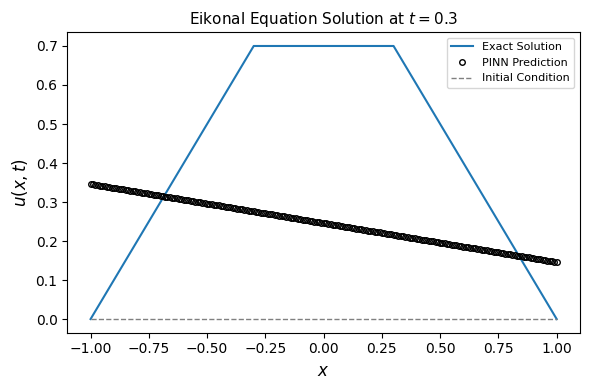

In [4]:

# --------------------------------------------------------
# Plotting: Compare PINN vs Exact at a chosen time
# --------------------------------------------------------
time_eval = 0.3   # choose time in [0, 1]
x_plot = np.linspace(-1, 1, 201)[:, None].astype(np.float32)
t_plot = np.full_like(x_plot, time_eval, dtype=np.float32)

# PINN prediction
u_pred = model(tf.concat([x_plot, t_plot], axis=1)).numpy()

# Exact Eikonal solution (from paper)
def u_exact_eikonal(x, t):
    relu = lambda z: np.maximum(z, 0.0)
    return relu(x + 1.0) - relu(x + t) - relu(x - t)

u_exact = u_exact_eikonal(x_plot, time_eval)

# Optional: Initial condition (final time in reverse-time formulation)
def u_initial(x):
    return np.zeros_like(x)  # u(T,x) = 0 here

# --------------------------------------------------------
# Plot
# --------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(x_plot, u_exact, '-', lw=1.5, label='Exact Solution')
plt.plot(x_plot, u_pred, 'o', mfc='None', mec='black', ms=4, label='PINN Prediction')
plt.plot(x_plot, u_initial(x_plot), '--', color='gray', lw=1, label='Initial Condition')

plt.xlabel(r"$x$", fontsize=12)
plt.ylabel(r"$u(x,t)$", fontsize=12)
plt.title(fr"Eikonal Equation Solution at $t={time_eval}$", fontsize=11)
plt.legend(fontsize=8, loc='upper right')
# plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
